### Practice Quiz

#### Part 1

Read in the cleaned version of the Amazon laptop dataset found in `amazon_laptop_cleaned.csv`. Create dummy variables for the `colour_new` variable.

In [5]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import seaborn as sns
df = pd.read_csv("../data/amazon_laptop_cleaned.csv")
df = pd.get_dummies(data=df, columns=["colour_new"], drop_first=True, dtype="int")
df.head()

,rating,total_rating,price,offer,brand,screen_size,hard_disk_size,ram,graphics_card,colour_new_Blue,colour_new_Grey,colour_new_Other,colour_new_Silver
0,4.3,63.0,85990.0,-28.0,Lenovo,14.0,512.0,16.0,Integrated,0,1,0,0
1,4.0,313.0,38000.0,-27.0,Lenovo,15.6,512.0,16.0,Integrated,0,1,0,0
2,3.1,62.0,16990.0,-60.0,Neopticon,14.1,128.0,4.0,Integrated,0,1,0,0
3,3.9,2071.0,24490.0,-38.0,acer,15.6,512.0,16.0,Integrated,0,1,0,0
4,4.0,48.0,99990.0,-17.0,ASUS,16.0,512.0,16.0,Integrated,0,0,0,0


#### Part 2

Fit a multiple linear regression model using `offer` and the dummy variables for `colour_new` as predictor variables and the log of `price` as a response variable.

In [13]:
# YOUR CODE HERE
from sklearn.linear_model import LinearRegression
df["log_price"] = np.log(df["price"])

X_mlr = df[["offer", "colour_new_Blue", "colour_new_Grey", "colour_new_Other", "colour_new_Silver"]]
y = df["log_price"]
mlr_model = LinearRegression()
mlr_model.fit(X_mlr, y)

#### Part 3

Print out the intercept and coefficients for the model fit in Part 2.

In [14]:
# YOUR CODE HERE
print("Intercept: ", mlr_model.intercept_)
print("Slope: ", mlr_model.coef_)

Intercept:  12.362807425284267
Slope:  [ 0.0311645  -0.73842571 -0.52125084 -0.16289393 -0.63136638]


#### Part 4

Get predictions for the response variable using the model fit in Part 2 and then compute the RMSE.

In [11]:
# YOUR CODE HERE
from sklearn.metrics import root_mean_squared_error, r2_score
mlr_preds = mlr_model.predict(X_mlr)
print("MLR RMSE: ", root_mean_squared_error(mlr_preds, y))

MLR RMSE:  0.49593430535720096


#### Part 5

Create a residual scatter plot of the predicted values on the x-axis and the residuals on the y-axis.

Text(0, 0.5, 'Residuals')

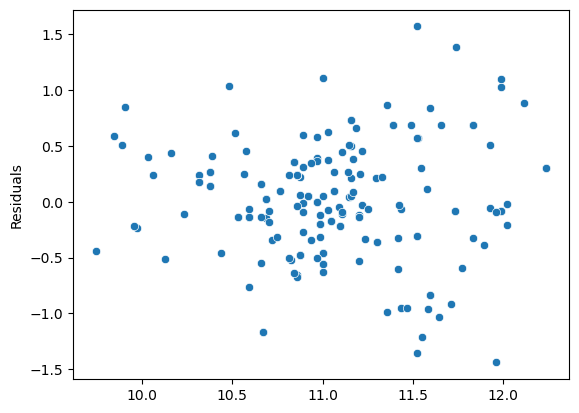

In [12]:
# YOUR CODE HERE
resids = y - mlr_preds
sns.scatterplot(x = mlr_preds, y = resids).set_ylabel("Residuals")

#### Part 6

Does there appear to be a violation of linearity for this model?

YOUR ANSWER HERE
No violation of linearity appear for this model.
No furnel or curve shape in the scatter plot.
The residual are randomly scattered around 0 with even spread across the full range of predicted values (~10.0 to 12.0)